## importing necessary libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import optuna
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, precision_score, recall_score, precision_recall_curve, confusion_matrix, classification_report

# Aesthetics
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## Loading dataset.

In [31]:
df = pd.read_csv('../data/raw/train.csv')
print(f"Dataset shape: {df.shape}")

# sort by CustomerId and step to preserve temporal order
df = df.sort_values(by=['CustomerId', 'TransactionStartTime'])
df.head(10)

Dataset shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
5184,TransactionId_51888,BatchId_22790,AccountId_1074,SubscriptionId_4836,CustomerId_1,UGX,256,ProviderId_4,ProductId_10,airtime,ChannelId_2,-10000.0,10000,2018-11-21T16:49:14Z,4,0
5178,TransactionId_24254,BatchId_4854,AccountId_1074,SubscriptionId_4836,CustomerId_10,UGX,256,ProviderId_4,ProductId_3,airtime,ChannelId_2,-10000.0,10000,2018-11-21T16:49:09Z,4,0
1122,TransactionId_11879,BatchId_61924,AccountId_661,SubscriptionId_4753,CustomerId_1001,UGX,256,ProviderId_5,ProductId_15,financial_services,ChannelId_3,10000.0,10000,2018-11-16T07:53:19Z,2,0
1148,TransactionId_36212,BatchId_23377,AccountId_661,SubscriptionId_4753,CustomerId_1001,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,10000.0,10000,2018-11-16T08:16:24Z,2,0
1149,TransactionId_64687,BatchId_30141,AccountId_4841,SubscriptionId_3829,CustomerId_1001,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-200.0,200,2018-11-16T08:16:36Z,2,0
1150,TransactionId_82586,BatchId_58031,AccountId_4841,SubscriptionId_3829,CustomerId_1001,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-5000.0,5000,2018-11-16T08:16:40Z,2,0
1158,TransactionId_84144,BatchId_118083,AccountId_661,SubscriptionId_4753,CustomerId_1001,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,5200.0,5200,2018-11-16T08:20:39Z,2,0
647,TransactionId_75390,BatchId_26788,AccountId_662,SubscriptionId_2325,CustomerId_1002,UGX,256,ProviderId_5,ProductId_1,airtime,ChannelId_3,1500.0,1500,2018-11-15T18:50:09Z,4,0
649,TransactionId_123518,BatchId_45913,AccountId_4841,SubscriptionId_3829,CustomerId_1002,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-75.0,75,2018-11-15T18:50:57Z,2,0
5835,TransactionId_98531,BatchId_18362,AccountId_662,SubscriptionId_2325,CustomerId_1002,UGX,256,ProviderId_5,ProductId_3,airtime,ChannelId_3,500.0,500,2018-11-22T19:46:47Z,4,0


In [32]:
df[:1].to_dict(orient='records')

[{'TransactionId': 'TransactionId_51888',
  'BatchId': 'BatchId_22790',
  'AccountId': 'AccountId_1074',
  'SubscriptionId': 'SubscriptionId_4836',
  'CustomerId': 'CustomerId_1',
  'CurrencyCode': 'UGX',
  'CountryCode': 256,
  'ProviderId': 'ProviderId_4',
  'ProductId': 'ProductId_10',
  'ProductCategory': 'airtime',
  'ChannelId': 'ChannelId_2',
  'Amount': -10000.0,
  'Value': 10000,
  'TransactionStartTime': '2018-11-21T16:49:14Z',
  'PricingStrategy': 4,
  'FraudResult': 0}]

### EDA.

In [33]:
def engineer_xente_features(data):
    df_feat = data.copy()
    
    # 1. Parse Datetime
    df_feat['TransactionStartTime'] = pd.to_datetime(df_feat['TransactionStartTime'])
    df_feat['Hour'] = df_feat['TransactionStartTime'].dt.hour
    df_feat['DayOfWeek'] = df_feat['TransactionStartTime'].dt.dayofweek
    df_feat['DayOfMonth'] = df_feat['TransactionStartTime'].dt.day
    
    # 2. Velocity / Frequency Engineering (Crucial for real fraud)
    # How many times has this CustomerId transacted in the whole dataset?
    df_feat['Customer_Transaction_Count'] = df_feat.groupby('CustomerId')['TransactionId'].transform('count')

    # # interactions between providerId, ProductId, productCategory, and channelId
    # df_feat['Interactions'] = df_feat['ProviderId'].astype(str) + '_' + \
    #                                             df_feat['ProductId'].astype(str) +'_'+\
    #                                             df_feat['ProductCategory'].astype(str) + '_' + \
    #                                             df_feat['ChannelId'].astype(str)
    
    # How many times has this ProviderId been used?
    df_feat['Provider_Transaction_Count'] = df_feat.groupby('ProviderId')['TransactionId'].transform('count')
    
    # Average transaction amount for this customer
    df_feat['Customer_Avg_Amount'] = df_feat.groupby('CustomerId')['Amount'].transform('mean')
    
    # Amount relative to the customer's historical average (Is this transaction unusually large?)
    df_feat['Amount_to_Customer_Avg_Ratio'] = df_feat['Amount'] / (df_feat['Customer_Avg_Amount'] + 1e-5) # Add small epsilon to avoid div by zero
    
    # Iscredit where Amount is positive (credit) or negative (debit)
    df_feat['IsCredit'] = (df_feat['Amount'] > 0).astype(int)
    
    # 3. Categorical Encoding
    # In real datasets, IDs like "ProviderId_1" need to be converted to numbers or One-Hot Encoded
    categorical_cols = ['ProviderId', 'ProductId', 
                            'ProductCategory', 
                            'ChannelId', #'Interactions'
                            ]
    # df_feat = pd.get_dummies(df_feat, columns=categorical_cols, drop_first=True)
    # use ordinal encoder for provider_product_iteraction
    # from sklearn.preprocessing import OrdinalEncoder
    # if 'Interactions' in df_feat.columns:
    #     oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    #     df_feat['Interactions_Encoded'] = oe.fit_transform(df_feat[['Interactions']])
    #     df_feat = df_feat.drop(columns=['Interactions'])
    
    # 4. Drop useless columns (Unique IDs that cause massive overfitting)
    cols_to_drop = ['BatchId', #'ProductCategory',
        'TransactionId', #'ProductId', 
        'AccountId', 'SubscriptionId', 
        'CustomerId','CurrencyCode', 
        'CountryCode', 'TransactionStartTime', 
        'Amount',
    ]

    df_feat = df_feat.drop(columns=[c for c in cols_to_drop if c in df_feat.columns])
    for col in categorical_cols:
            df_feat[col] = df_feat[col].astype('category')
    return df_feat

print("Engineering features...")
df_ml = engineer_xente_features(df)
print(f"New shape: {df_ml.shape}")

Engineering features...
New shape: (95662, 15)


In [34]:
df.groupby(['ProductCategory', 'ChannelId'])['FraudResult'].value_counts()

ProductCategory     ChannelId    FraudResult
airtime             ChannelId_1  0                300
                    ChannelId_2  0               4491
                                 1                  4
                    ChannelId_3  0              39376
                                 1                 14
                    ChannelId_5  0                842
data_bundles        ChannelId_1  0                 20
                    ChannelId_3  0               1513
                    ChannelId_5  0                 80
financial_services  ChannelId_1  0                107
                                 1                  4
                    ChannelId_2  0              32628
                                 1                  1
                    ChannelId_3  0              12509
                                 1                156
movies              ChannelId_1  0                  2
                    ChannelId_3  0                171
                    ChannelId_5  0   

In [35]:
df_ml.iloc[np.where((df['ProductCategory'] == 'airtime') & (df['FraudResult'] == 1))]

,ProviderId,ProductId,ProductCategory,ChannelId,Value,PricingStrategy,FraudResult,Hour,DayOfWeek,DayOfMonth,Customer_Transaction_Count,Provider_Transaction_Count,Customer_Avg_Amount,Amount_to_Customer_Avg_Ratio,IsCredit
95108,ProviderId_6,ProductId_3,airtime,ChannelId_3,500000,2,1,18,1,12,11,34186,1.188545e+06,0.420682,1
73829,ProviderId_3,ProductId_10,airtime,ChannelId_3,200000,1,1,10,5,26,18,3084,1.830556e+05,1.092564,1
73830,ProviderId_3,ProductId_10,airtime,ChannelId_3,200000,1,1,10,5,26,18,3084,1.830556e+05,1.092564,1
9283,ProviderId_1,ProductId_10,airtime,ChannelId_3,500000,0,1,13,1,27,54,5643,5.424900e+05,0.921676,1
14531,ProviderId_1,ProductId_10,airtime,ChannelId_3,500000,4,1,9,1,4,54,5643,5.424900e+05,0.921676,1
38399,ProviderId_6,ProductId_10,airtime,ChannelId_3,600000,2,1,16,6,23,205,34186,2.478291e+05,2.421023,1
4911,ProviderId_5,ProductId_3,airtime,ChannelId_3,500000,4,1,8,2,21,132,14542,5.187902e+04,9.637808,1
36728,ProviderId_5,ProductId_3,airtime,ChannelId_3,500000,4,1,7,5,22,132,14542,5.187902e+04,9.637808,1
43595,ProviderId_5,ProductId_3,airtime,ChannelId_3,500000,4,1,8,4,28,132,14542,5.187902e+04,9.637808,1
49863,ProviderId_5,ProductId_3,airtime,ChannelId_3,500000,4,1,16,3,3,132,14542,5.187902e+04,9.637808,1


### Split dataset.

In [36]:
X = df_ml.drop('FraudResult', axis=1)
y = df_ml['FraudResult']

# Stratified split ensures fraud cases are distributed evenly
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Handle extreme imbalance for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale Positive Weight: {scale_pos_weight:.2f}")

Scale Positive Weight: 495.94


Training model...
Baseline AUPRC: 0.8048

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19094
           1       0.58      0.97      0.72        39

    accuracy                           1.00     19133
   macro avg       0.79      0.99      0.86     19133
weighted avg       1.00      1.00      1.00     19133



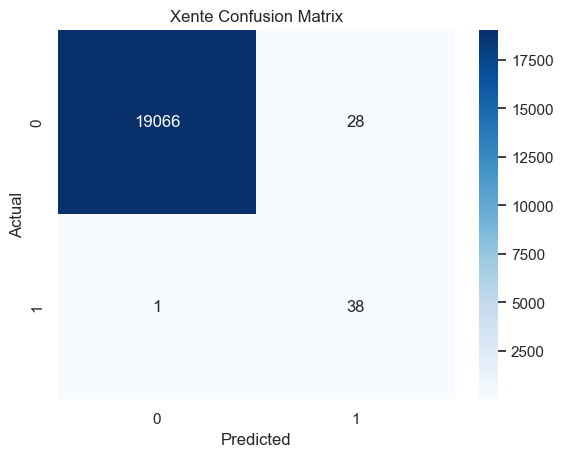

In [37]:
# Setup XGBoost (We bypass Optuna for a moment just to get a baseline score)
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    scale_pos_weight=scale_pos_weight,
    learning_rate=0.05,
    max_depth=6,
    n_estimators=200, enable_categorical=True,
    random_state=42
)

print("Training model...")
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)
preds_proba = model.predict_proba(X_test)[:, 1]

# Evaluate
auprc = average_precision_score(y_test, preds_proba)
print(f"Baseline AUPRC: {auprc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, preds))

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Xente Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

###  Hyperparameter Tuning with Optuna


In [38]:
def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'scale_pos_weight': scale_pos_weight,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'n_estimators': 1500, #trial.suggest_int('n_estimators', 50, 300),
        'early_stopping_rounds': 20
    }
    
    model = xgb.XGBClassifier(**param, random_state=42, enable_categorical=True)
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)
    
    # Predict probabilities for AUPRC
    preds_proba = model.predict_proba(X_test)[:, 1]
    
    # Primary Metric: AUPRC
    auprc = average_precision_score(y_test, preds_proba)
    print(f"Best number of estimators is {model.best_iteration}")
    return auprc

# Create study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) # Set to 20 or 50 for deep tuning

print('Best trial parameters:', study.best_trial.params)
print('Best AUPRC:', study.best_trial.value)

[I 2026-06-01 21:20:19,360] A new study created in memory with name: no-name-9739fa2c-22d7-411b-8ae1-f6d91d4b517f
[I 2026-06-01 21:20:20,788] Trial 0 finished with value: 0.5851185536433081 and parameters: {'learning_rate': 0.018926885686067634, 'max_depth': 6, 'subsample': 0.8986748106966251, 'colsample_bytree': 0.7450348957616155}. Best is trial 0 with value: 0.5851185536433081.


Best number of estimators is 28


[I 2026-06-01 21:20:21,483] Trial 1 finished with value: 0.5446318424672795 and parameters: {'learning_rate': 0.03253755376068101, 'max_depth': 6, 'subsample': 0.8784516643136123, 'colsample_bytree': 0.605591061830438}. Best is trial 0 with value: 0.5851185536433081.


Best number of estimators is 2


[I 2026-06-01 21:20:24,932] Trial 2 finished with value: 0.7666754613770042 and parameters: {'learning_rate': 0.021121547034782633, 'max_depth': 9, 'subsample': 0.9521322382066423, 'colsample_bytree': 0.8447572156002491}. Best is trial 2 with value: 0.7666754613770042.


...

Best number of estimators is 0


[I 2026-06-01 21:20:49,135] Trial 8 finished with value: 0.7990553393403562 and parameters: {'learning_rate': 0.13435296908948674, 'max_depth': 3, 'subsample': 0.8240740466499165, 'colsample_bytree': 0.6477551930612964}. Best is trial 5 with value: 0.8324149985635608.


Best number of estimators is 125


[I 2026-06-01 21:20:51,380] Trial 9 finished with value: 0.5503602593911194 and parameters: {'learning_rate': 0.02967926520154767, 'max_depth': 5, 'subsample': 0.9165973041885469, 'colsample_bytree': 0.9308785856775873}. Best is trial 5 with value: 0.8324149985635608.


Best number of estimators is 41
Best trial parameters: {'learning_rate': 0.05980251061976809, 'max_depth': 8, 'subsample': 0.9398338216459659, 'colsample_bytree': 0.7638821193106502}
Best AUPRC: 0.8324149985635608


Primary Metric (AUPRC): 0.8324
Secondary Metric (Precision): 0.5588
Secondary Metric (Recall): 0.9744

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19094
           1       0.56      0.97      0.71        39

    accuracy                           1.00     19133
   macro avg       0.78      0.99      0.85     19133
weighted avg       1.00      1.00      1.00     19133



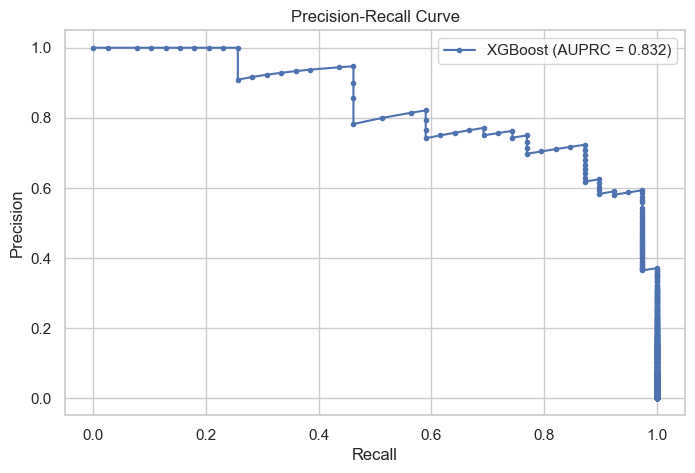

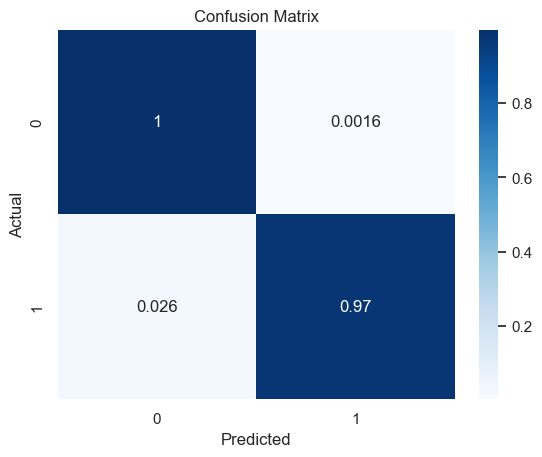

In [39]:
# Train best model
best_params = study.best_trial.params
best_params['n_estimators'] = 1500
best_params['objective'] = 'binary:logistic'
best_params['eval_metric'] = 'aucpr'
best_params['scale_pos_weight'] = scale_pos_weight

final_model = xgb.XGBClassifier(**best_params, random_state=42, 
                                early_stopping_rounds=20, enable_categorical=True,
                                )
final_model.fit(X_train, y_train,
                eval_set=[(X_test, y_test)],
                verbose=False)

# Predictions
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Metrics
auprc = average_precision_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Primary Metric (AUPRC): {auprc:.4f}")
print(f"Secondary Metric (Precision): {precision:.4f}")
print(f"Secondary Metric (Recall): {recall:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 5))
plt.plot(recall_vals, precision_vals, marker='.', label=f'XGBoost (AUPRC = {auprc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm, annot=True, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Model Explainability (SHAP).

In [40]:
import json
X_test_sampled = X_test.sample(n=min(5000, len(X_test)), random_state=42)

booster = final_model.get_booster()
config = json.loads(booster.save_config())
if config['learner']['learner_model_param']['base_score'] == '[5E-1]':
    config['learner']['learner_model_param']['base_score'] = '0.5'
booster.load_config(json.dumps(config))

explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test_sampled)

shap.summary_plot(shap_values, X_test_sampled)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:ProviderId: category, ProductId: category, ProductCategory: category, ChannelId: category

In [ ]:
X_test[:1]

,Value,PricingStrategy,Hour,DayOfWeek,DayOfMonth,Customer_Transaction_Count,Provider_Transaction_Count,Customer_Avg_Amount,Amount_to_Customer_Avg_Ratio,IsCredit,ChannelId_ChannelId_2,ChannelId_ChannelId_3,ChannelId_ChannelId_5,Interactions_Encoded
43719,10,2,9,4,28,25,38189,5060.0,-0.001976,0,True,False,False,78.0
